# Airbnb price prediction: exploration, features and results

Goal: predict `log_price`, the log of the nightly price, for Airbnb listings in six US cities. The test set has 51,877 listings; the training set has 22,234.

This notebook tells the story of the project: what the data looks like, which features matter and why, and how the final model performs. The modelling code is in [`src/features.py`](../src/features.py) and [`src/train.py`](../src/train.py). The results shown at the end come from `python src/train.py`.

In [1]:
import sys, json
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from features import add_basic_features, parse_amenities

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
train = pd.read_csv("../data/airbnb_train.csv")
train.shape

(22234, 28)

## 1. The target

Prices are heavily right-skewed. The log transform makes the target close to normally distributed, which is why it is the variable to predict.

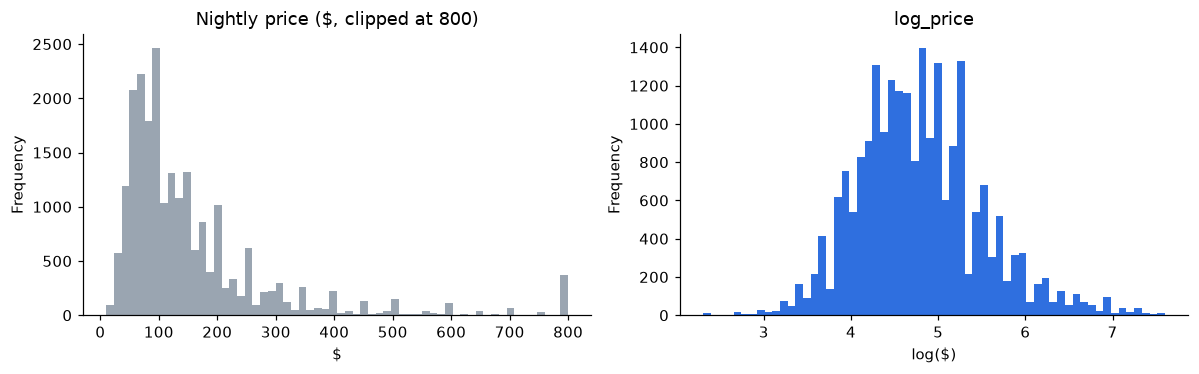

median price: $110 | mean: $161


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
np.exp(train.log_price).clip(upper=800).plot.hist(bins=60, ax=axes[0], color="#9aa5b1")
axes[0].set(title="Nightly price ($, clipped at 800)", xlabel="$")
train.log_price.plot.hist(bins=60, ax=axes[1], color="#2f6fdf")
axes[1].set(title="log_price", xlabel="log($)")
plt.tight_layout(); plt.show()
print(f"median price: ${np.exp(train.log_price).median():.0f} | mean: ${np.exp(train.log_price).mean():.0f}")

## 2. What drives the price?

Room type and capacity dominate, and the city matters too.

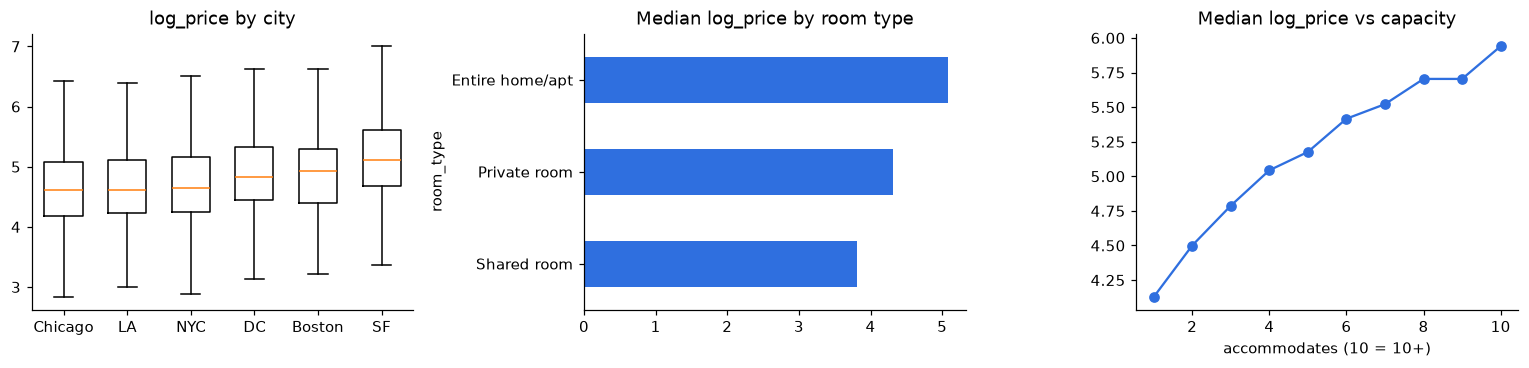

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
order = train.groupby("city").log_price.median().sort_values().index
for i, c in enumerate(order):
    axes[0].boxplot(train.loc[train.city == c, "log_price"], positions=[i], widths=.6, showfliers=False)
axes[0].set_xticks(range(len(order)), order); axes[0].set_title("log_price by city")
train.groupby("room_type").log_price.median().sort_values().plot.barh(ax=axes[1], color="#2f6fdf")
axes[1].set_title("Median log_price by room type")
train.groupby(train.accommodates.clip(upper=10)).log_price.median().plot(ax=axes[2], marker="o", color="#2f6fdf")
axes[2].set(title="Median log_price vs capacity", xlabel="accommodates (10 = 10+)")
plt.suptitle(""); plt.tight_layout(); plt.show()

### Location within a city

Inside a city, location is a major factor. In New York, prices are highest in Manhattan and fall with distance from Midtown. This is why I added a `dist_to_center_km` feature and kept the `neighbourhood` column.

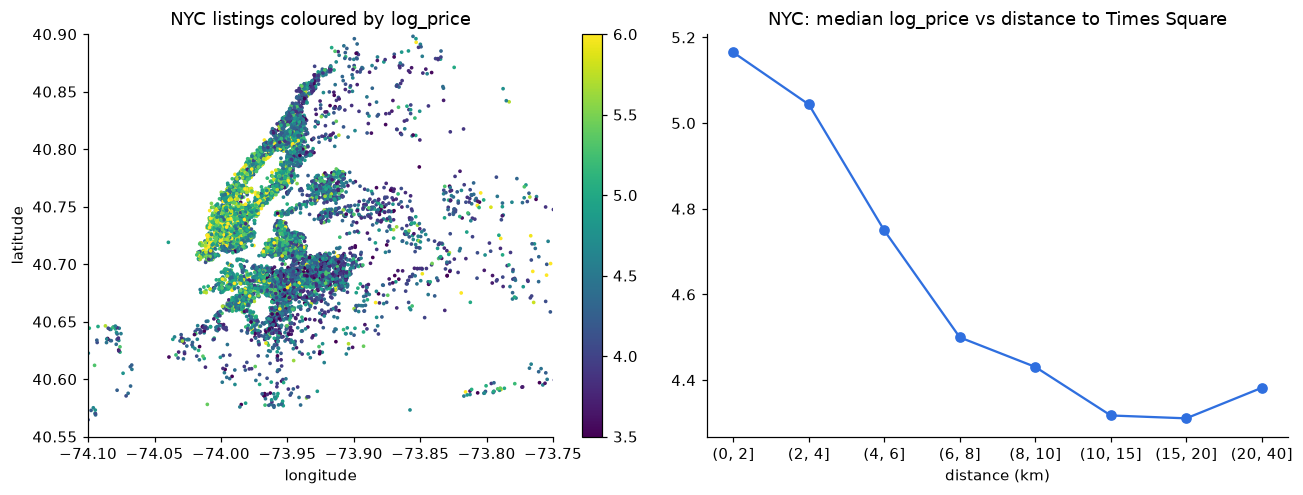

In [4]:
X = add_basic_features(train.drop(columns="log_price"))
nyc = train.city.eq("NYC")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
sc = axes[0].scatter(train.longitude[nyc], train.latitude[nyc], c=train.log_price[nyc], s=2, cmap="viridis", vmin=3.5, vmax=6)
axes[0].set(title="NYC listings coloured by log_price", xlabel="longitude", ylabel="latitude", xlim=(-74.1, -73.75), ylim=(40.55, 40.9))
plt.colorbar(sc, ax=axes[0])
d = X.loc[nyc, "dist_to_center_km"]
train[nyc].groupby(pd.cut(d, [0, 2, 4, 6, 8, 10, 15, 20, 40])).log_price.median().plot(ax=axes[1], marker="o", color="#2f6fdf")
axes[1].set(title="NYC: median log_price vs distance to Times Square", xlabel="distance (km)")
plt.tight_layout(); plt.show()

### Amenities

The v1 of the project **dropped** the `amenities` column. Once parsed, it holds more than a hundred distinct amenities, and several are strongly linked to price. The table shows the gap in median `log_price` between listings with and without each amenity (a correlation, not a causal effect).

In [5]:
amen = train.amenities.apply(parse_amenities)
am = amen.explode().dropna()
common = am.value_counts()
common = common[common > 0.05 * len(train)].index
rows = []
for a in common:
    has = amen.apply(lambda l: a in l)
    rows.append((a, has.mean(), train.log_price[has].median() - train.log_price[~has].median()))
uplift = pd.DataFrame(rows, columns=["amenity", "share", "log_price_gap"]).set_index("amenity").sort_values("log_price_gap")
pd.concat([uplift.head(5), uplift.tail(8)]).style.format({"share": "{:.0%}", "log_price_gap": "{:+.2f}"})

,share,log_price_gap
amenity,,
pets live on this property,13%,-0.28
lock on bedroom door,25%,-0.24
dog(s),7%,-0.15
breakfast,11%,-0.14
first aid kit,37%,-0.04
bathtub,5%,+0.31
heating,91%,+0.32
indoor fireplace,12%,+0.33
gym,10%,+0.33


### Text

`name` and `description` were also dropped in v1. Now they go through a TF-IDF. The Ridge model uses the TF-IDF matrix directly; for LightGBM it is compressed to 50 dimensions with a truncated SVD. To see which words carry information, the cell below fits a Ridge model **on the text alone** and lists the terms with the largest coefficients.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
print(f"distinct amenities: {am.nunique()}")
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=20, sublinear_tf=True, stop_words="english")
T = vec.fit_transform(X.text)
coef = pd.Series(Ridge(alpha=3).fit(T, train.log_price).coef_, index=vec.get_feature_names_out()).sort_values()
pd.DataFrame({"lowers price": coef.head(12).index, "raises price": coef.tail(12).index[::-1]})

distinct amenities: 122


,lowers price,raises price
0,room,inauguration
1,shared,bedrooms
2,hostel,super bowl
3,roommates,superbowl
4,private bedroom,villa
5,bushwick,beds
6,shared room,bowl
7,bedroom bedroom,malibu
8,cozy,baths
9,share,shoots


Most terms are what you would expect: *shared*, *hostel* and *roommates* lower the price, while *villa*, *penthouse* and *malibu* raise it. More surprising are ***inauguration*** and ***super bowl***. These are listings posted at event prices, for the presidential inauguration in Washington (January 2017) and the Super Bowl. They are real outliers, and they come back in the error analysis below.

## 3. What changed compared with v1

| | v1 (course project) | v2 (this repository) |
|---|---|---|
| Features | 17 raw columns; amenities, text and dates dropped; **`id` used as a feature** | parsed amenities, text (TF-IDF), host tenure, days since last review, distance to downtown |
| Categoricals | `LabelEncoder` (imposes an arbitrary order) | One-hot encoding (rare categories grouped together) |
| Preprocessing | Fitted on the full data, applied by hand to test | scikit-learn `Pipeline`/`ColumnTransformer`, **refitted inside each CV fold**  |
| Dimensionality | PCA to 13 components before tree models | No PCA on tabular features (trees don't need it). SVD only on the sparse text matrix. |
| Validation | Single 75/25 split | 5-fold cross-validation |
| Model | Gradient Boosting (sklearn) | LightGBM (Ridge kept as a comparison) |

## 4. Results

In [7]:
res = json.load(open("../results/metrics.json"))
table = pd.DataFrame(res).T
table.loc["v1 (Gradient Boosting, 75/25 split)"] = [np.nan, np.nan, 0.5318]
table.sort_values("r2").style.format("{:.4f}", na_rep="-").background_gradient(subset=["r2"], cmap="Blues")

,rmse,mae,r2
Baseline (mean),0.7188,0.5621,-0.0002
"v1 (Gradient Boosting, 75/25 split)",-,-,0.5318
Ridge,0.4010,0.2899,0.6887
LightGBM,0.3785,0.2709,0.7226


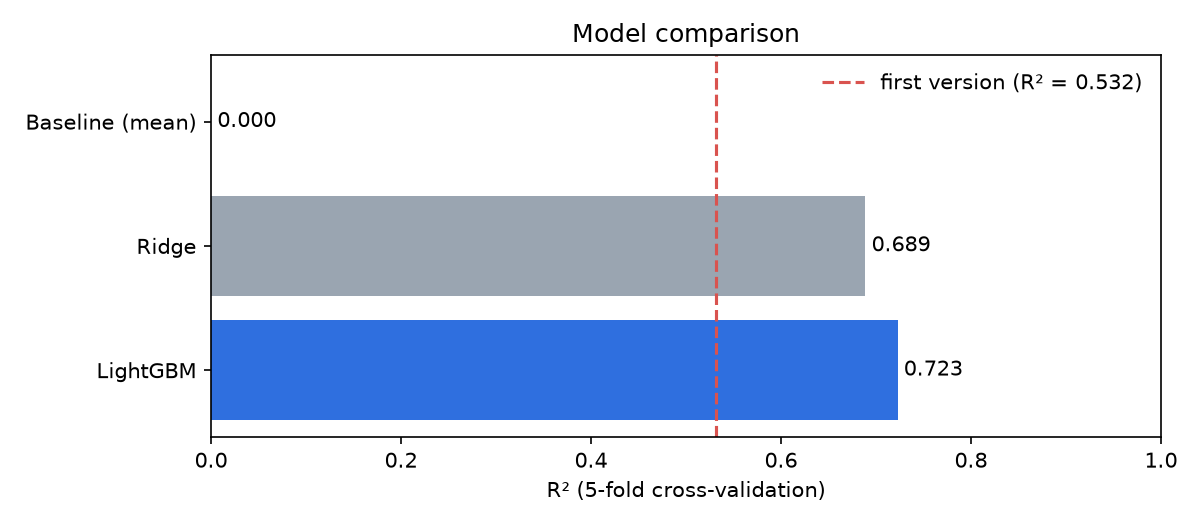

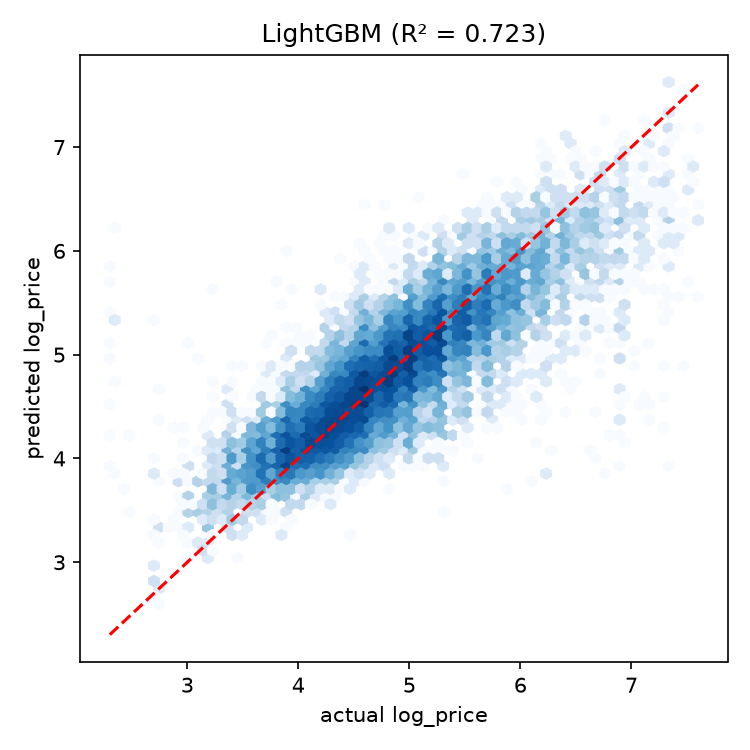

In [8]:
display(Image("../reports/figures/model_comparison.png", width=700))
display(Image("../reports/figures/pred_vs_actual.png", width=450))

### Which features does LightGBM use?

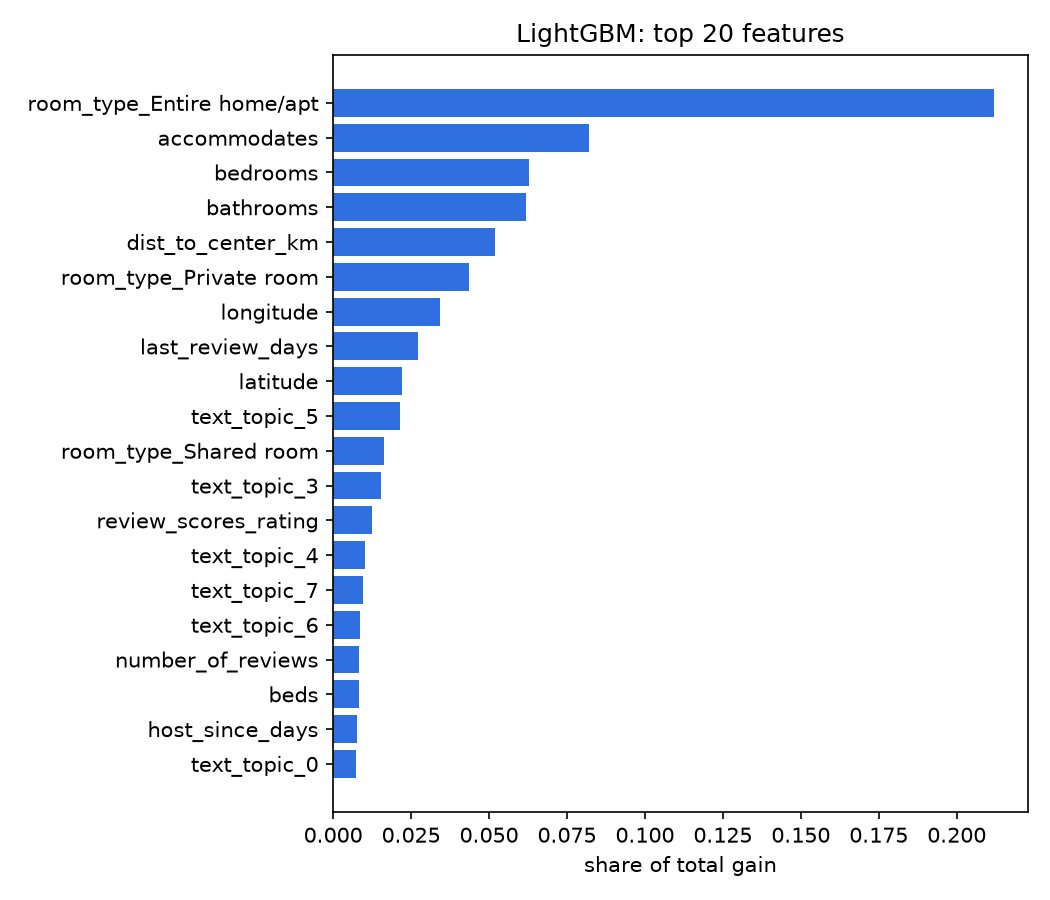

In [9]:
display(Image("../reports/figures/feature_importance.png", width=560))

### Error analysis

Where is the model least accurate? The table shows RMSE on `log_price` by city and by room type, using the cross-validated predictions.

In [10]:
cv = pd.read_csv("../results/cv_predictions.csv")
cv["sq_err"] = (cv.log_price - cv.pred) ** 2
by = lambda col: cv.groupby(col).agg(n=("sq_err", "size"), rmse=("sq_err", lambda s: np.sqrt(s.mean()))).sort_values("rmse")
display(by("city").round(3)); display(by("room_type").round(3))

,n,rmse
city,,
NYC,9739,0.350
LA,6672,0.365
Boston,1028,0.375
Chicago,1127,0.384
SF,1924,0.423
DC,1744,0.505


,n,rmse
room_type,,
Private room,9219,0.373
Entire home/apt,12348,0.374
Shared room,667,0.510


The model is most accurate in NYC and LA, the cities with the most training data. It is least accurate in **DC**, where many listings were priced for the 2017 inauguration and not at their usual rate, and on **shared rooms**, a small and heterogeneous category.

## 5. Takeaways

- **Feature engineering accounts for most of the gain.** Using the columns v1 had dropped (amenities, text, dates) and adding geography moves the linear model alone from R² ≈ 0.45 to 0.69.
- **Text is very informative.** A simple Ridge model on TF-IDF gets close to LightGBM.
- **Putting the preprocessing inside the pipeline matters.** The encoders and the TF-IDF are refitted inside each fold, so the validation data never leaks into training.

Next steps: tune hyperparameters (Optuna), use sentence embeddings instead of TF-IDF, and use the prices of nearby listings as a feature.